## Imports and load data

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scanpy as sc
import os
main_path = os.getcwd()

from skbio.stats.composition import clr, multiplicative_replacement

In [2]:
def generate_frequency_vector(complete_df, matching_field, groupby, leiden_clusters, transform=True, meta_field=None, min_tiles=1, min_perc=0):
    if min_perc >= 1:
        raise ValueError('Minimum percentage should be in the range 0-1')
    
    lr_data = list()
    lr_label = list()
    lr_samples = list()

    for sample in pd.unique(complete_df[matching_field].unique()):
        samples_df = complete_df[complete_df[matching_field] == sample]
        samples_df = samples_df[samples_df[groupby].isin(leiden_clusters)]

        num_tiles = samples_df.shape[0]
        if num_tiles < min_tiles:
            print(f'Sample: {sample} - {num_tiles} tiles. Skipping')
            continue
        
        # samples_features = [0]*len(leiden_clusters)
        samples_features = dict()
        for clust_id in leiden_clusters:
            samples_features[clust_id] = 0

        clusters_slide, clusters_counts = np.unique(samples_df[groupby], return_counts=True)
        for clust_id, count in zip(clusters_slide, clusters_counts):
            # samples_features[int(clust_id)] = count

            if (count / num_tiles) > min_perc:
                samples_features[clust_id] = count
            else:
                samples_features[clust_id] = 0

        # samples_features = np.array(samples_features, dtype=np.float64)
        samples_features = np.fromiter(samples_features.values(), dtype=np.float64)
        samples_features = np.array(samples_features) / np.sum(samples_features)
        if transform:
            samples_features = multiplicative_replacement(np.reshape(samples_features, (1,-1)))
            samples_features = clr(np.reshape(samples_features, (1,-1)))

        lr_samples.append(sample)
        lr_data.append(samples_features)

        try:
            samples_label = samples_df[meta_field].values[0]
            lr_label.append(samples_label)
        except:
            continue
            
    sample_rep_df = pd.DataFrame(data=lr_data, columns=leiden_clusters)
    sample_rep_df[matching_field] = lr_samples

    if len(lr_label) > 0:
        sample_rep_df[meta_field] = lr_label
        lr_label = np.stack(lr_label)
        lr_data = np.stack(lr_data)
    
        return lr_data, lr_label, sample_rep_df

    else:
        return sample_rep_df

In [3]:
ssl_adata_train = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/gri-crc/adata-train.hdf5'))
ssl_adata_valid = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/gri-crc/adata-valid.hdf5'))

In [4]:
leiden_clusters = np.unique(ssl_adata_train.obs['leiden'].unique())
ssl_adata_train.obs['samples'] = ssl_adata_train.obs['samples'].astype(float)
ssl_adata_valid.obs['samples'] = ssl_adata_valid.obs['samples'].astype(float)

In [5]:
train_df = generate_frequency_vector(complete_df=ssl_adata_train.obs, matching_field='samples', groupby='leiden', leiden_clusters=leiden_clusters, transform=False)
valid_df =  generate_frequency_vector(complete_df=ssl_adata_valid.obs, matching_field='samples', groupby='leiden', leiden_clusters=leiden_clusters, transform=False)

In [6]:
train_df

,0,1,10,11,12,13,14,15,16,17,...,19,2,3,4,5,6,7,8,9,samples
0,0.040000,0.120000,0.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.080000,0.040000,0.240000,0.000000,0.000000,0.040000,0.080000,0.040000,2070253.0
1,0.049383,0.061728,0.222222,0.024691,0.135802,0.024691,0.061728,0.012346,0.000000,0.012346,...,0.000000,0.012346,0.061728,0.074074,0.024691,0.074074,0.000000,0.061728,0.086420,197863.0
2,0.060000,0.000000,0.040000,0.040000,0.340000,0.020000,0.000000,0.060000,0.000000,0.040000,...,0.000000,0.080000,0.060000,0.060000,0.000000,0.000000,0.000000,0.000000,0.200000,197737.0
3,0.024691,0.098765,0.098765,0.061728,0.000000,0.111111,0.000000,0.061728,0.074074,0.024691,...,0.012346,0.074074,0.061728,0.037037,0.024691,0.037037,0.111111,0.049383,0.024691,177191.0
4,0.000000,0.087500,0.000000,0.075000,0.000000,0.125000,0.012500,0.225000,0.012500,0.062500,...,0.025000,0.100000,0.012500,0.012500,0.025000,0.050000,0.075000,0.037500,0.000000,177141.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.000000,0.258065,0.064516,0.032258,0.000000,0.096774,0.000000,0.096774,0.000000,0.032258,...,0.000000,0.064516,0.129032,0.096774,0.000000,0.064516,0.000000,0.064516,0.000000,177051.0
266,0.064516,0.000000,0.032258,0.000000,0.322581,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.064516,0.000000,0.032258,0.000000,0.000000,0.000000,0.000000,0.483871,197661.0
267,0.000000,0.148148,0.000000,0.037037,0.000000,0.148148,0.037037,0.111111,0.000000,0.037037,...,0.000000,0.000000,0.000000,0.000000,0.222222,0.111111,0.000000,0.111111,0.000000,2070391.0
268,0.000000,0.133333,0.000000,0.066667,0.000000,0.000000,0.033333,0.133333,0.000000,0.166667,...,0.000000,0.066667,0.000000,0.000000,0.133333,0.100000,0.000000,0.066667,0.000000,177043.0


In [ ]:
clinical = pd.read_spss(os.path.join(main_path, 'data/metadata/GRI TMA database_2025.sav'))

## Survival

In [8]:
censor_dict = {'No recurrence':0, 'Death, non-cancer cause':1, 'Recurrence':1}
clinical['os_event_ind'] = clinical['DFS_status_July2020'].map(censor_dict)
clinical['os_event_data'] = clinical['DFS_months_2020'].values

/tmp/ipykernel_3789450/3927179611.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clinical['os_event_ind'] = clinical['DFS_status_July2020'].map(censor_dict)
/tmp/ipykernel_3789450/3927179611.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clinical['os_event_data'] = clinical['DFS_months_2020'].values


In [9]:
train_df_clr = generate_frequency_vector(complete_df=ssl_adata_train.obs, matching_field='samples', groupby='leiden', leiden_clusters=leiden_clusters, transform=True)
valid_df_clr =  generate_frequency_vector(complete_df=ssl_adata_valid.obs, matching_field='samples', groupby='leiden', leiden_clusters=leiden_clusters, transform=True)

In [10]:
train_df_surv = train_df_clr.merge(clinical[['BB_numbers_Pete', 'os_event_ind', 'os_event_data']], left_on='samples', right_on='BB_numbers_Pete')
valid_df_surv = valid_df_clr.merge(clinical[['BB_numbers_Pete', 'os_event_ind', 'os_event_data']], left_on='samples', right_on='BB_numbers_Pete')

all_df_surv = pd.concat([train_df_surv, valid_df_surv]).dropna()

In [11]:
from lifelines import CoxPHFitter, KaplanMeierFitter

cph = CoxPHFitter(penalizer=0.01, l1_ratio=0.5)
cph.fit(all_df_surv[list(leiden_clusters)+['os_event_ind', 'os_event_data']], duration_col='os_event_data', event_col='os_event_ind')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 507 total observations, 180 right-censored observations>
             duration col = 'os_event_data'
                event col = 'os_event_ind'
                penalizer = 0.01
                 l1 ratio = 0.5
      baseline estimation = breslow
   number of observations = 507
number of events observed = 327
   partial log-likelihood = -1822.11
         time fit was run = 2025-10-13 16:36:43 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
0           0.00       1.00       0.06            -0.11             0.11                 0.90                 1.12
1           0.02       1.02       0.06            -0.10             0.14                 0.90                 1.15
10         -0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
11          0.00       1.00       0.05            -0.10             0.10                 0.91                 1.11
12          0.03       1.03       0.05            -0.06             0.12                 0.94                 1.13
13         -0.07       0.93       0.05            -0.18             0.03                 0.84                 1.03
14          0.04       1.04       0.06            -0.08             0.15                 0.93                 1.16
15         -0.07       0.94       0.05            -0.16             0.03                 0.85                 1.03
16         -0.00       1.00       0.05            -0.11             0.10                 0.90                 1.11
17          0.04       1.04       0.05            -0.05             0.14                 0.95                 1.15
18          0.00       1.00       0.05            -0.10             0.10                 0.91                 1.11
19          0.01       1.01       0.08            -0.13             0.16                 0.87                 1.18
2          -0.02       0.98       0.06            -0.15             0.10                 0.86                 1.11
3           0.01       1.01       0.06            -0.10             0.12                 0.90                 1.12
4          -0.00       1.00       0.00            -0.01             0.01                 0.99                 1.01
5           0.04       1.04       0.05            -0.05             0.14                 0.95                 1.15
6          -0.06       0.94       0.06            -0.17             0.05                 0.85                 1.05
7          -0.03       0.97       0.06            -0.14             0.09                 0.87                 1.09
8          -0.09       0.92       0.06            -0.20             0.02                 0.82                 1.02
9          -0.10       0.91       0.06            -0.21             0.01                 0.81                 1.01

            cmp to     z    p   -log2(p)
covariate                               
0             0.00  0.01 0.99       0.02
1             0.00  0.30 0.76       0.39
10            0.00 -0.00 1.00       0.00
11            0.00  0.09 0.93       0.10
12            0.00  0.68 0.50       1.01
13            0.00 -1.33 0.18       2.44
14            0.00  0.62 0.53       0.91
15            0.00 -1.34 0.18       2.47
16            0.00 -0.04 0.97       0.04
17            0.00  0.87 0.38       1.38
18            0.00  0.04 0.97       0.04
19            0.00  0.18 0.85       0.23
2             0.00 -0.35 0.73       0.46
3             0.00  0.11 0.91       0.13
4             0.00 -0.00 1.00       0.00
5             0.00  0.85 0.39       1.34
6             0.00 -1.04 0.30       1.75
7             0.00 -0.45 0.65       0.62
8             0.00 -1.55 0.12       3.03
9             0.00 -1.71 0.09       3.52
---
Concordance = 0.49
Partial AIC = 3684.21
log-likelihood ratio test = 14.79 on 20 df
-log2(p) of ll-ratio test = 0.34

## CMS 

In [12]:
# Two CMS columns - this one has less missing values
clinical['CMS_Raheleh_withoutlabels'].isna().value_counts()

False    435
True     352
Name: CMS_Raheleh_withoutlabels, dtype: int64

In [13]:
clinical['CMS_Raheleh_withoutlabels'].value_counts()

CMS2    232
CMS1     95
CMS4     78
CMS3     30
Name: CMS_Raheleh_withoutlabels, dtype: int64

In [14]:
train_df_cms = train_df.merge(clinical[['BB_numbers_Pete', 'CMS_Raheleh_withoutlabels']], left_on='samples', right_on='BB_numbers_Pete')
valid_df_cms = valid_df.merge(clinical[['BB_numbers_Pete', 'CMS_Raheleh_withoutlabels']], left_on='samples', right_on='BB_numbers_Pete')

all_df_cms = pd.concat([train_df_cms, valid_df_cms])

In [15]:
train_df_cms['CMS_Raheleh_withoutlabels'].value_counts()

CMS2    79
CMS1    32
CMS4    27
CMS3    13
Name: CMS_Raheleh_withoutlabels, dtype: int64

In [16]:
valid_df_cms['CMS_Raheleh_withoutlabels'].value_counts()

CMS2    91
CMS4    33
CMS1    28
CMS3    10
Name: CMS_Raheleh_withoutlabels, dtype: int64

### Associative - all cases

In [17]:
all_df_cms.columns

Index(['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '3', '4', '5', '6', '7', '8', '9', 'samples', 'BB_numbers_Pete',
       'CMS_Raheleh_withoutlabels'],
      dtype='object')

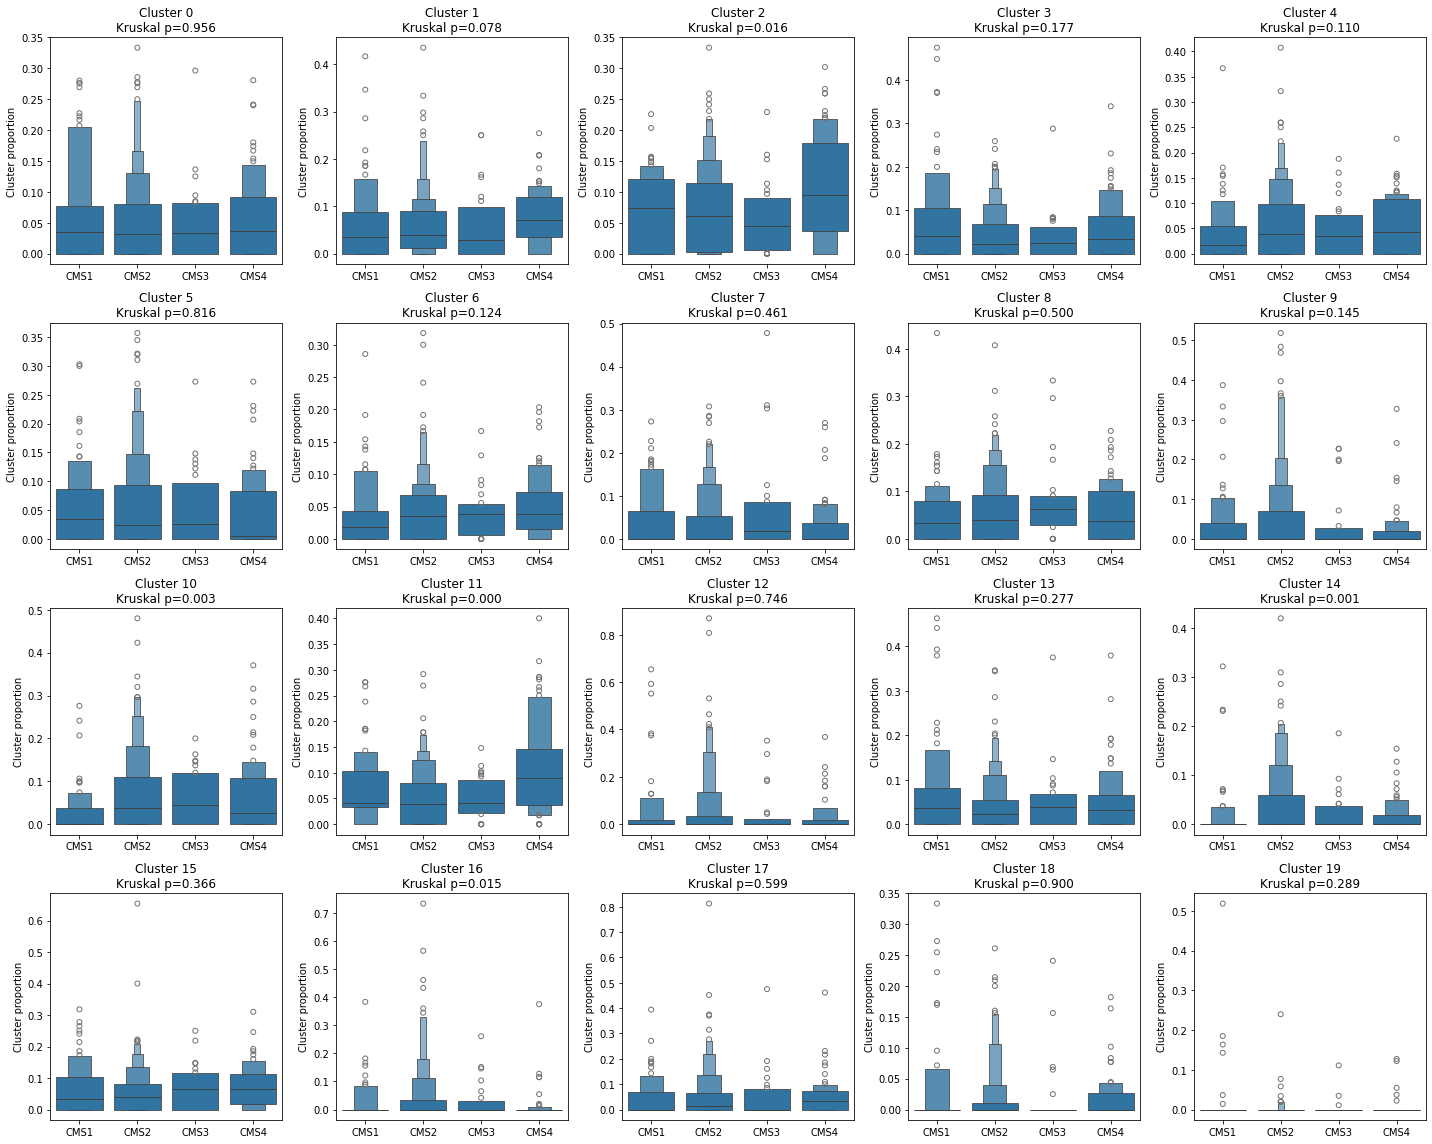

In [18]:
from scipy import stats

fig, axs = plt.subplots(nrows=4, ncols=5, figsize=(20,16))
axs = axs.flatten()

for i, cluster in enumerate(sorted([int(c) for c in leiden_clusters])):
    sns.boxenplot(all_df_cms.reset_index(), x='CMS_Raheleh_withoutlabels', y=str(cluster), ax=axs[i])
    stat, p_val = stats.kruskal(all_df_cms[all_df_cms['CMS_Raheleh_withoutlabels'] == 'CMS1'][str(cluster)],
                                all_df_cms[all_df_cms['CMS_Raheleh_withoutlabels'] == 'CMS2'][str(cluster)],
                                all_df_cms[all_df_cms['CMS_Raheleh_withoutlabels'] == 'CMS3'][str(cluster)],
                                all_df_cms[all_df_cms['CMS_Raheleh_withoutlabels'] == 'CMS4'][str(cluster)],
                                nan_policy='omit')
    axs[i].set_title(f'Cluster {cluster}\nKruskal p={p_val:.3f}')
    axs[i].set_xlabel("")
    axs[i].set_ylabel("Cluster proportion")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Cluster proportion')

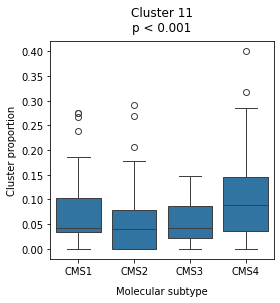

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4,4))

cluster = 11
sns.boxplot(all_df_cms.reset_index(), x='CMS_Raheleh_withoutlabels', y=str(cluster), ax=ax)

stat, p_val = stats.kruskal(all_df_cms[all_df_cms['CMS_Raheleh_withoutlabels'] == 'CMS1'][str(cluster)],
                                all_df_cms[all_df_cms['CMS_Raheleh_withoutlabels'] == 'CMS2'][str(cluster)],
                                all_df_cms[all_df_cms['CMS_Raheleh_withoutlabels'] == 'CMS3'][str(cluster)],
                                all_df_cms[all_df_cms['CMS_Raheleh_withoutlabels'] == 'CMS4'][str(cluster)],
                                nan_policy='omit')

if p_val < 0.001:
    ax.set_title(f'Cluster {cluster}\np < 0.001', pad=10) 
else:
    ax.set_title(f'Cluster {cluster}\nKruskal p < {p_val:3f}') 
ax.set_xlabel("Molecular subtype", labelpad=10)
ax.set_ylabel("Cluster proportion")

## Budding

In [23]:
clinical['Tumour_budding'].value_counts()

low <10     532
high >10    225
Name: Tumour_budding, dtype: int64

In [24]:
train_df_bud = train_df.merge(clinical[['BB_numbers_Pete', 'Tumour_budding']], left_on='samples', right_on='BB_numbers_Pete')
valid_df_bud = valid_df.merge(clinical[['BB_numbers_Pete', 'Tumour_budding']], left_on='samples', right_on='BB_numbers_Pete')

all_df_bud = pd.concat([train_df_bud, valid_df_bud])
all_df_bud

,0,1,10,11,12,13,14,15,16,17,...,3,4,5,6,7,8,9,samples,BB_numbers_Pete,Tumour_budding
0,0.040000,0.120000,0.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.040000,0.240000,0.000000,0.000000,0.040000,0.080000,0.040000,2070253.0,2070253.0,NaN
1,0.049383,0.061728,0.222222,0.024691,0.135802,0.024691,0.061728,0.012346,0.000000,0.012346,...,0.061728,0.074074,0.024691,0.074074,0.000000,0.061728,0.086420,197863.0,197863.0,low <10
2,0.060000,0.000000,0.040000,0.040000,0.340000,0.020000,0.000000,0.060000,0.000000,0.040000,...,0.060000,0.060000,0.000000,0.000000,0.000000,0.000000,0.200000,197737.0,197737.0,low <10
3,0.024691,0.098765,0.098765,0.061728,0.000000,0.111111,0.000000,0.061728,0.074074,0.024691,...,0.061728,0.037037,0.024691,0.037037,0.111111,0.049383,0.024691,177191.0,177191.0,low <10
4,0.000000,0.087500,0.000000,0.075000,0.000000,0.125000,0.012500,0.225000,0.012500,0.062500,...,0.012500,0.012500,0.025000,0.050000,0.075000,0.037500,0.000000,177141.0,177141.0,low <10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,0.000000,0.115385,0.192308,0.000000,0.000000,0.000000,0.038462,0.000000,0.038462,0.000000,...,0.000000,0.000000,0.115385,0.076923,0.153846,0.153846,0.000000,2070406.0,2070406.0,low <10
252,0.000000,0.137931,0.034483,0.137931,0.000000,0.068966,0.000000,0.275862,0.000000,0.241379,...,0.000000,0.034483,0.000000,0.034483,0.000000,0.000000,0.000000,177034.0,177034.0,low <10
253,0.066667,0.066667,0.100000,0.033333,0.133333,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.166667,0.066667,0.000000,0.033333,0.000000,0.066667,0.200000,197714.0,197714.0,high >10
254,0.000000,0.160000,0.000000,0.040000,0.000000,0.040000,0.040000,0.080000,0.040000,0.000000,...,0.000000,0.000000,0.320000,0.080000,0.120000,0.040000,0.000000,2070266.0,2070266.0,low <10


In [25]:
all_df_bud['Tumour_budding'].value_counts()

low <10     358
high >10    148
Name: Tumour_budding, dtype: int64

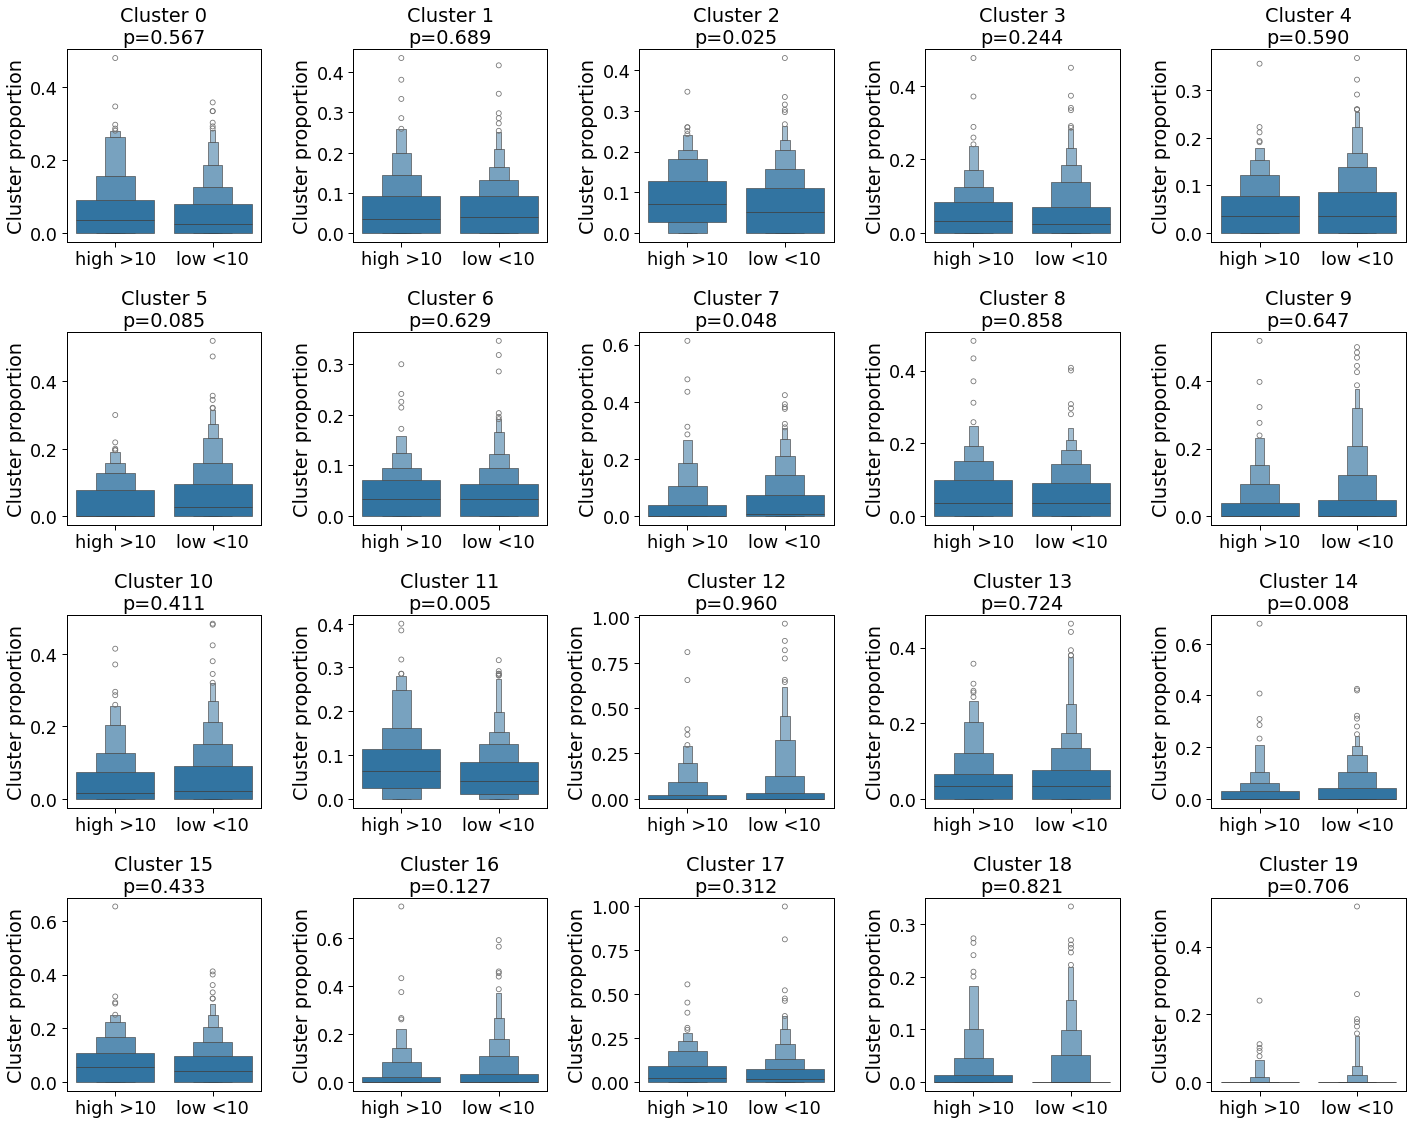

In [26]:
from scipy import stats

fig, axs = plt.subplots(nrows=4, ncols=5, figsize=(20,16))
axs = axs.flatten()

for i, cluster in enumerate(sorted([int(c) for c in leiden_clusters])):
    sns.boxenplot(all_df_bud.reset_index(), x='Tumour_budding', y=str(cluster), ax=axs[i])
    stat, p_val = stats.mannwhitneyu(all_df_bud[all_df_bud['Tumour_budding'] == 'low <10'][str(cluster)].values,
                                all_df_bud[all_df_bud['Tumour_budding'] == 'high >10'][str(cluster)].values,
                                nan_policy='omit')
    axs[i].set_title(f'Cluster {cluster}\np={p_val:.3f}')
    axs[i].set_xlabel("")
    axs[i].set_ylabel("Cluster proportion")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3789450/4116794206.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['High (>10)', 'Low (<10)'])


Text(0, 0.5, 'Cluster proportion')

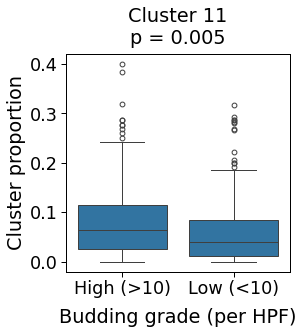

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4,4))

cluster = 11
sns.boxplot(all_df_bud.reset_index(), x='Tumour_budding', y=str(cluster), ax=ax)

stat, p_val = stats.mannwhitneyu(all_df_bud[all_df_bud['Tumour_budding'] == 'low <10'][str(cluster)],
                                all_df_bud[all_df_bud['Tumour_budding'] == 'high >10'][str(cluster)],
                                nan_policy='omit')

if p_val < 0.001:
    ax.set_title(f'Cluster {cluster}\nMann-Whitney-U p < 0.001', pad=10) 
else:
    ax.set_title(f'Cluster {cluster}\np = {np.round(p_val, 3)}', pad=10) 
ax.set_xlabel("Budding grade (per HPF)", labelpad=10)
ax.set_xticklabels(['High (>10)', 'Low (<10)'])
ax.set_ylabel("Cluster proportion")
